# Регрессия SI



In [ ]:
# Установка библиотек для Google Colab
!pip -q install xgboost lightgbm openpyxl seaborn


In [ ]:
# Загрузка исходного файла с данными

import os
from google.colab import files

DATA_PATH = '/content/drug_data.xlsx'

if not os.path.exists(DATA_PATH):
    uploaded = files.upload()
    if 'drug_data.xlsx' not in uploaded:

        first_file = next(iter(uploaded.keys()))
        os.rename(first_file, DATA_PATH)

os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)
print(f'Файл данных: {DATA_PATH}')
print('Папки reports/ и models/ готовы')


Файл данных: /content/drug_data.xlsx
Папки reports/ и models/ готовы


## Основной код

РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ SI (СЕЛЕКТИВНЫЙ ИНДЕКС)
Размер данных: (1001, 210)
Целевая переменная: SI
Диапазон SI: [0.011, 15620.600]
Медиана SI: 3.846
Корреляция SI с CC50/IC50: 1.000000
Удаляем 18 константных признаков
Удаляем 32 высококоррелированных признаков
Итоговое количество признаков: 160

Применяем импутацию пропущенных значений...
Импутация завершена.
Обучающая выборка: (800, 160)
Тестовая выборка: (201, 160)

Анализ распределения SI:
Среднее: 72.509
Стандартное отклонение: 684.483
Асимметрия: 18.013
Эксцесс: 361.417
Образцов с SI > 8: 357 (35.7%)

1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ
----------------------------------------
Определено 12 моделей
Включены модели с трансформацией для работы с асимметричным распределением

2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ
----------------------------------------
Обучение Linear Regression...
  RMSE: 15987.1822 ± 31341.6105
Обучение Ridge Regression...
  RMSE: 279.2045 ± 109.3942
Обучение Lasso Regression...
  RMSE: 255.4112 ± 115.4393
Обучение ElasticNet...
  R

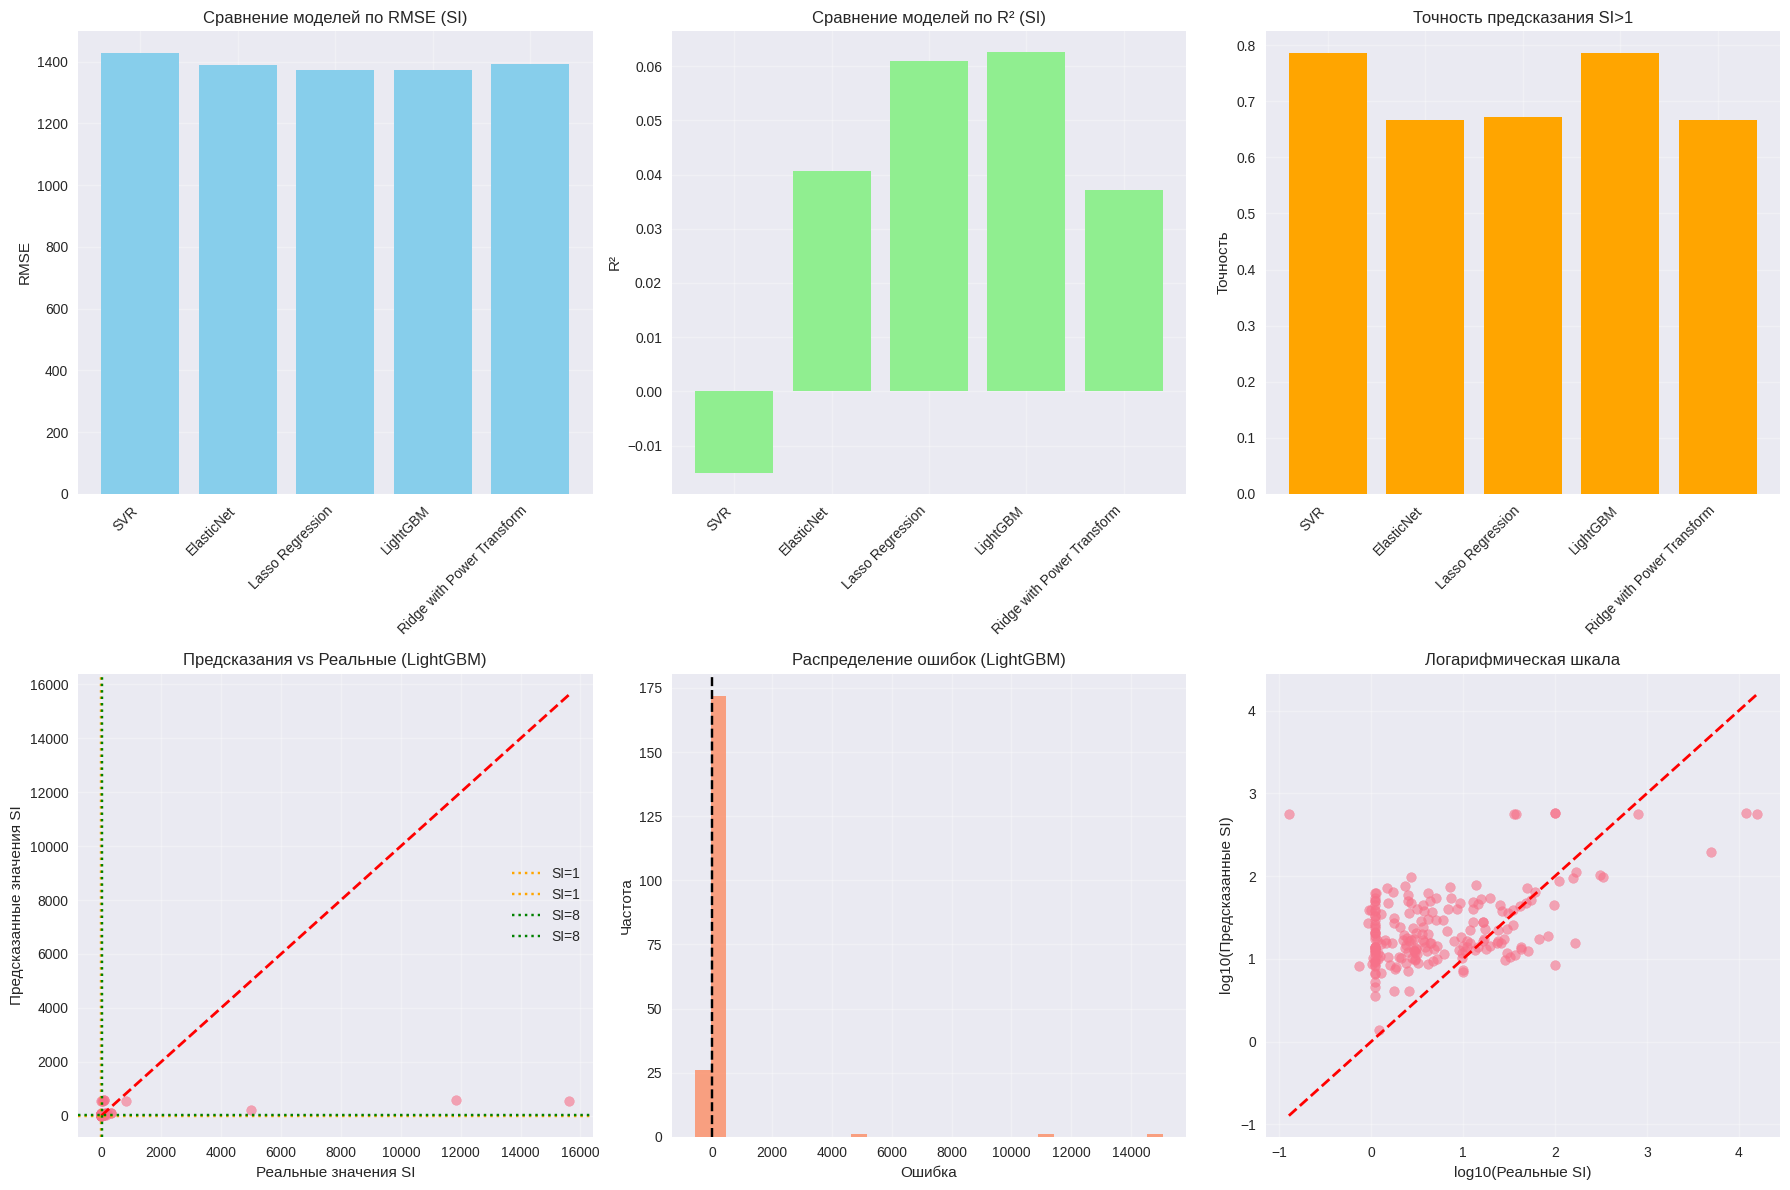


6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
Результаты

МОДЕЛИРОВАНИЕ SI ЗАВЕРШЕНО!
Лучшая модель: LightGBM
RMSE: 1372.1746
R²: 0.0626


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

class SIPredictor:
    """Класс для прогнозирования SI (Selectivity Index)"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.best_model = None
        self.scaler = StandardScaler()

    def load_and_prepare_data(self):
        """Загрузка и подготовка данных"""
        print("="*60)
        print("РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ SI (СЕЛЕКТИВНЫЙ ИНДЕКС)")
        print("="*60)

        # Загрузка данных
        df = pd.read_excel(DATA_PATH)

        # Переименование целевых столбцов
        df = df.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})

        # Удаление индексного столбца
        if 'Unnamed: 0' in df.columns:
            df = df.drop('Unnamed: 0', axis=1)

        # Разделение на признаки и целевую переменную
        self.target_col = 'SI'
        feature_cols = [col for col in df.columns if col not in ['IC50', 'CC50', 'SI']]

        X = df[feature_cols].copy()
        y = df[self.target_col].copy()

        print(f"Размер данных: {X.shape}")
        print(f"Целевая переменная: {self.target_col}")
        print(f"Диапазон {self.target_col}: [{y.min():.3f}, {y.max():.3f}]")
        print(f"Медиана {self.target_col}: {y.median():.3f}")

        # Анализ связи SI с IC50 и CC50
        calculated_SI = df['CC50'] / df['IC50']
        correlation = np.corrcoef(y, calculated_SI)[0,1]
        print(f"Корреляция SI с CC50/IC50: {correlation:.6f}")

        # Проверка и удаление константных признаков
        constant_features = X.columns[X.nunique() <= 1]
        if len(constant_features) > 0:
            print(f"Удаляем {len(constant_features)} константных признаков")
            X = X.drop(constant_features, axis=1)

        # Удаление высококоррелированных признаков
        corr_matrix = X.corr().abs()
        upper_triangle = np.triu(np.ones_like(corr_matrix), k=1)
        high_corr_pairs = np.where((corr_matrix > 0.95) & upper_triangle)

        features_to_remove = set()
        for i in range(len(high_corr_pairs[0])):
            idx1, idx2 = high_corr_pairs[0][i], high_corr_pairs[1][i]
            feature1, feature2 = X.columns[idx1], X.columns[idx2]
            corr1 = abs(np.corrcoef(X[feature1], y)[0,1])
            corr2 = abs(np.corrcoef(X[feature2], y)[0,1])
            if corr1 < corr2:
                features_to_remove.add(feature1)
            else:
                features_to_remove.add(feature2)

        if features_to_remove:
            print(f"Удаляем {len(features_to_remove)} высококоррелированных признаков")
            X = X.drop(list(features_to_remove), axis=1)

        print(f"Итоговое количество признаков: {X.shape[1]}")

        # Разделение на обучающую и тестовую выборки
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Применение импутации для обработки пропущенных значений (после разделения, чтобы избежать утечки данных)
        # Это обеспечит, что X_train и X_test не содержат NaN, прежде чем они будут переданы в пайплайны моделей,
        # что устранит ошибки с моделями, не поддерживающими NaN напрямую (например, MLPRegressor).
        print("\nПрименяем импутацию пропущенных значений...")
        imputer = SimpleImputer(strategy='mean')
        self.X_train = pd.DataFrame(imputer.fit_transform(self.X_train), columns=X.columns)
        self.X_test = pd.DataFrame(imputer.transform(self.X_test), columns=X.columns)
        print("Импутация завершена.")

        print(f"Обучающая выборка: {self.X_train.shape}")
        print(f"Тестовая выборка: {self.X_test.shape}")

        # Анализ распределения SI
        print(f"\nАнализ распределения SI:")
        print(f"Среднее: {y.mean():.3f}")
        print(f"Стандартное отклонение: {y.std():.3f}")
        print(f"Асимметрия: {y.skew():.3f}")
        print(f"Эксцесс: {y.kurtosis():.3f}")

        # SI > 8 (высокая селективность)
        high_selectivity = (y > 8).sum()
        print(f"Образцов с SI > 8: {high_selectivity} ({high_selectivity/len(y)*100:.1f}%)")

        return X, y

    def define_models(self):
        """Определение моделей для тестирования"""
        print(f"\n1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ")
        print("-"*40)

        # Учитывая что SI имеет сильную асимметрию, добавим модели с трансформацией
        # SimpleImputer теперь применяется до разделения на обучающую и тестовую выборки
        self.models = {
            'Linear Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', LinearRegression())
            ]),

            'Ridge Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', Ridge(random_state=42))
            ]),

            'Lasso Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', Lasso(random_state=42, max_iter=2000))
            ]),

            'ElasticNet': Pipeline([
                ('scaler', StandardScaler()),
                ('model', ElasticNet(random_state=42, max_iter=2000))
            ]),

            'Ridge with Power Transform': Pipeline([
                ('transformer', PowerTransformer(method='yeo-johnson')),
                ('scaler', StandardScaler()),
                ('model', Ridge(random_state=42))
            ]),

            'Random Forest': Pipeline([
                ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
            ]),

            'Extra Trees': Pipeline([
                ('model', ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1))
            ]),

            'Gradient Boosting': Pipeline([
                ('model', GradientBoostingRegressor(random_state=42))
            ]),

            'XGBoost': xgb.XGBRegressor(
                random_state=42, n_jobs=-1, verbosity=0 # XGBoost handles NaNs natively
            ),

            'LightGBM': lgb.LGBMRegressor(
                random_state=42, n_jobs=-1, verbosity=-1 # LightGBM handles NaNs natively
            ),

            'SVR': Pipeline([
                ('scaler', StandardScaler()),
                ('model', SVR(kernel='rbf'))
            ]),

            'Neural Network': Pipeline([
                ('scaler', StandardScaler()),
                ('model', MLPRegressor(random_state=42, max_iter=500))
            ])
        }

        print(f"Определено {len(self.models)} моделей")
        print("Включены модели с трансформацией для работы с асимметричным распределением")

    def evaluate_models(self):
        """Оценка всех моделей с кросс-валидацией"""
        print(f"\n2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ")
        print("-"*40)

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        for name, model in self.models.items():
            print(f"Обучение {name}...")

            try:
                cv_scores = cross_val_score(
                    model, self.X_train, self.y_train,
                    cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
                )

                rmse_scores = np.sqrt(-cv_scores)

                self.results[name] = {
                    'cv_rmse_mean': rmse_scores.mean(),
                    'cv_rmse_std': rmse_scores.std(),
                    'cv_scores': rmse_scores
                }

                print(f"  RMSE: {rmse_scores.mean():.4f} \u00b1 {rmse_scores.std():.4f}")
            except Exception as e:
                print(f"  Ошибка: {str(e)}")
                self.results[name] = {
                    'cv_rmse_mean': np.inf,
                    'cv_rmse_std': 0,
                    'cv_scores': [np.inf]
                }

        # Сортировка результатов (исключая модели с ошибками)
        valid_results = {k: v for k, v in self.results.items() if v['cv_rmse_mean'] != np.inf}
        sorted_models = sorted(
            valid_results.items(),
            key=lambda x: x[1]['cv_rmse_mean']
        )

        print(f"\nРАНГИ МОДЕЛЕЙ:")
        for i, (name, metrics) in enumerate(sorted_models, 1):
            print(f"{i:2d}. {name:<25} | RMSE: {metrics['cv_rmse_mean']:.4f}")

        return sorted_models

    def hyperparameter_tuning(self, top_models=3):
        """Настройка гиперпараметров для лучших моделей"""
        print(f"\n3. НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
        print("-"*40)

        sorted_models = sorted(
            {k: v for k, v in self.results.items() if v['cv_rmse_mean'] != np.inf}.items(),
            key=lambda x: x[1]['cv_rmse_mean']
        )

        param_grids = {
            'Random Forest': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [10, 20, None],
                'model__min_samples_split': [2, 5, 10]
            },

            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 6, 10],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0]
            },

            'LightGBM': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 6, 10],
                'learning_rate': [0.01, 0.1, 0.2]
            },

            'Ridge Regression': {
                'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
            },

            'Ridge with Power Transform': {
                'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
            },

            'Lasso Regression': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0]
            }
        }

        tuned_models = {}

        for name, _ in sorted_models[:top_models]:
            if name in param_grids:
                print(f"Настройка {name}...")

                try:
                    grid_search = GridSearchCV(
                        self.models[name],
                        param_grids[name],
                        cv=3,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1
                    )

                    grid_search.fit(self.X_train, self.y_train)

                    tuned_models[name] = {
                        'model': grid_search.best_estimator_,
                        'best_params': grid_search.best_params_,
                        'best_score': -grid_search.best_score_
                    }

                    print(f"  Лучший RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
                    print(f"  Параметры: {grid_search.best_params_}")
                except Exception as e:
                    print(f"  Ошибка при настройке: {str(e)}")
            else:
                try:
                    model = self.models[name]
                    model.fit(self.X_train, self.y_train)

                    tuned_models[name] = {
                        'model': model,
                        'best_params': {},
                        'best_score': 0
                    }
                except Exception as e:
                    print(f"  Ошибка при обучении {name}: {str(e)}")

        return tuned_models

    def final_evaluation(self, tuned_models):
        """Финальная оценка на тестовой выборке"""
        print(f"\n4. ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
        print("-"*40)

        final_results = {}

        for name, model_info in tuned_models.items():
            try:
                model = model_info['model']

                y_pred = model.predict(self.X_test)

                rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
                mae = mean_absolute_error(self.y_test, y_pred)
                r2 = r2_score(self.y_test, y_pred)

                # Дополнительные метрики для SI
                # Процент предсказаний с правильным знаком селективности (SI > 1)
                correct_selectivity = np.mean((self.y_test > 1) == (y_pred > 1))

                # Процент правильных предсказаний высокой селективности (SI > 8)
                correct_high_sel = np.mean((self.y_test > 8) == (y_pred > 8))

                final_results[name] = {
                    'model': model,
                    'y_pred': y_pred,
                    'rmse': rmse,
                    'mae': mae,
                    'r2': r2,
                    'correct_selectivity': correct_selectivity,
                    'correct_high_selectivity': correct_high_sel
                }

                print(f"{name}:")
                print(f"  RMSE: {rmse:.4f}")
                print(f"  MAE:  {mae:.4f}")
                print(f"  R\u00b2:   {r2:.4f}")
                print(f"  Точность SI>1: {correct_selectivity:.1%}")
                print(f"  Точность SI>8: {correct_high_sel:.1%}")
                print()

            except Exception as e:
                print(f"Ошибка при оценке {name}: {str(e)}")

        if final_results:
            best_model_name = min(final_results.keys(),
                                 key=lambda x: final_results[x]['rmse'])
            self.best_model = final_results[best_model_name]['model']

            print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
            print(f"RMSE: {final_results[best_model_name]['rmse']:.4f}")
        else:
            print("Нет успешно обученных моделей")
            return {}, ""

        return final_results, best_model_name

    def create_visualizations(self, final_results, best_model_name):
        """Создание визуализаций результатов"""
        print(f"\n5. СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
        print("-"*40)

        if not final_results:
            print("Нет результатов для визуализации")
            return

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Сравнение RMSE
        model_names = list(final_results.keys())
        rmse_values = [final_results[name]['rmse'] for name in model_names]

        axes[0, 0].bar(range(len(model_names)), rmse_values, color='skyblue')
        axes[0, 0].set_xticks(range(len(model_names)))
        axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 0].set_ylabel('RMSE')
        axes[0, 0].set_title('Сравнение моделей по RMSE (SI)')
        axes[0, 0].grid(True, alpha=0.3)

        # Сравнение R²
        r2_values = [final_results[name]['r2'] for name in model_names]

        axes[0, 1].bar(range(len(model_names)), r2_values, color='lightgreen')
        axes[0, 1].set_xticks(range(len(model_names)))
        axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 1].set_ylabel('R²')
        axes[0, 1].set_title('Сравнение моделей по R² (SI)')
        axes[0, 1].grid(True, alpha=0.3)

        # Точность предсказания селективности
        sel_values = [final_results[name]['correct_selectivity'] for name in model_names]

        axes[0, 2].bar(range(len(model_names)), sel_values, color='orange')
        axes[0, 2].set_xticks(range(len(model_names)))
        axes[0, 2].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 2].set_ylabel('Точность')
        axes[0, 2].set_title('Точность предсказания SI>1')
        axes[0, 2].grid(True, alpha=0.3)

        # Предсказания vs реальные значения (лучшая модель)
        best_results = final_results[best_model_name]
        y_pred = best_results['y_pred']

        axes[1, 0].scatter(self.y_test, y_pred, alpha=0.6)
        axes[1, 0].plot([self.y_test.min(), self.y_test.max()],
                       [self.y_test.min(), self.y_test.max()], 'r--', lw=2)
        axes[1, 0].axhline(y=1, color='orange', linestyle=':', label='SI=1')
        axes[1, 0].axvline(x=1, color='orange', linestyle=':', label='SI=1')
        axes[1, 0].axhline(y=8, color='green', linestyle=':', label='SI=8')
        axes[1, 0].axvline(x=8, color='green', linestyle=':', label='SI=8')
        axes[1, 0].set_xlabel('Реальные значения SI')
        axes[1, 0].set_ylabel('Предсказанные значения SI')
        axes[1, 0].set_title(f'Предсказания vs Реальные ({best_model_name})')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Распределение ошибок
        errors = self.y_test - y_pred

        axes[1, 1].hist(errors, bins=30, alpha=0.7, color='coral')
        axes[1, 1].axvline(0, color='black', linestyle='--')
        axes[1, 1].set_xlabel('Ошибка')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 1].set_title(f'Распределение ошибок ({best_model_name})')
        axes[1, 1].grid(True, alpha=0.3)

        # Логарифмическая шкала для SI
        axes[1, 2].scatter(np.log10(self.y_test + 0.1), np.log10(y_pred + 0.1), alpha=0.6)
        axes[1, 2].plot([np.log10(self.y_test + 0.1).min(), np.log10(self.y_test + 0.1).max()],
                       [np.log10(self.y_test + 0.1).min(), np.log10(self.y_test + 0.1).max()], 'r--', lw=2)
        axes[1, 2].set_xlabel('log10(Реальные SI)')
        axes[1, 2].set_ylabel('log10(Предсказанные SI)')
        axes[1, 2].set_title('Логарифмическая шкала')
        axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('reports/si_regression_results.png', dpi=300, bbox_inches='tight')
        plt.show()

    def save_results(self, final_results, best_model_name):
        """Сохранение результатов"""
        print(f"\n6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
        print("-"*40)

        if not final_results:
            print("Нет результатов для сохранения")
            return

        # Сохраняем результаты в CSV
        results_summary = []
        for name, metrics in final_results.items():
            results_summary.append({
                'Model': name,
                'RMSE': metrics['rmse'],
                'MAE': metrics['mae'],
                'R2': metrics['r2'],
                'Selectivity_Accuracy': metrics['correct_selectivity'],
                'High_Selectivity_Accuracy': metrics['correct_high_selectivity']
            })

        results_df = pd.DataFrame(results_summary)
        results_df.to_csv('reports/si_regression_results.csv', index=False)

        # Сохраняем предсказания лучшей модели
        predictions_df = pd.DataFrame({
            'True_SI': self.y_test.values,
            'Predicted_SI': final_results[best_model_name]['y_pred'],
            'Error': self.y_test.values - final_results[best_model_name]['y_pred'],
            'True_Selective': (self.y_test.values > 1).astype(int),
            'Pred_Selective': (final_results[best_model_name]['y_pred'] > 1).astype(int),
            'True_High_Selective': (self.y_test.values > 8).astype(int),
            'Pred_High_Selective': (final_results[best_model_name]['y_pred'] > 8).astype(int)
        })
        predictions_df.to_csv('reports/si_predictions.csv', index=False)

        print("Результаты")

def main():
    """Основная функция для обучения моделей регрессии SI"""

    predictor = SIPredictor()

    X, y = predictor.load_and_prepare_data()
    predictor.define_models()
    sorted_models = predictor.evaluate_models()
    tuned_models = predictor.hyperparameter_tuning(top_models=5)
    final_results, best_model_name = predictor.final_evaluation(tuned_models)
    predictor.create_visualizations(final_results, best_model_name)
    predictor.save_results(final_results, best_model_name)

    if final_results:
        print(f"\nМОДЕЛИРОВАНИЕ SI ЗАВЕРШЕНО!")
        print(f"Лучшая модель: {best_model_name}")
        print(f"RMSE: {final_results[best_model_name]['rmse']:.4f}")
        print(f"R\u00b2: {final_results[best_model_name]['r2']:.4f}")

if __name__ == "__main__":
    main()